In [1]:
import scanpy as sc
import anndata
import glob
import os
import pandas as pd

# Define donors
donors = ["TSP21", "TSP25", "TSP27"]

# Dictionary to store cell type counts for each dataset
cell_type_counts = {}

for donor in donors:
    # Load the h5ad file
    adata = sc.read_h5ad(f"05_Merged-PerDonor-QC-h5ad/{donor}_merged_processed.h5ad")
    
    # Count occurrences of each cell type
    counts = adata.obs["cell_ontology_class"].value_counts()
    
    # Store in dictionary
    cell_type_counts[donor] = counts

# Convert dictionary to DataFrame and fill NaNs with 0 (since not all cell types are present in every dataset)
df = pd.DataFrame(cell_type_counts).fillna(0).astype(int)

# Rename columns for better readability (extracting dataset identifiers)
df.columns = [name.split("_")[0] for name in df.columns]

# Display the matrix
print(df)

# Save to CSV if needed
df.to_csv("05_Merged-PerDonor-QC-h5ad/TSP_cell_type_counts_matrix.csv")


                                           TSP21  TSP25  TSP27
cell_ontology_class                                           
acinar cell                                 1178      0      0
acinar cell of salivary gland               1365   2222      0
activated cd4-positive, alpha-beta t cell      0     11    183
activated cd8-positive, alpha-beta t cell      0    289    263
adventitial cell                               0    141      0
...                                          ...    ...    ...
type l enteroendocrine cell                    0      8      3
vascular associated smooth muscle cell      1806    177    409
vein endothelial cell                        718    925     40
ventricular cardiac muscle cell              317     36     61
vestibular dark cell                          35     14      0

[156 rows x 3 columns]


In [3]:
import scanpy as sc
import pandas as pd

# Define donors
donors = ["TSP21", "TSP25", "TSP27"]

# Dictionary to store top 30 cell type counts for each dataset
tissues_counts = {}

for donor in donors:
    # Load the h5ad file
    adata = sc.read_h5ad(f"05_Merged-PerDonor-QC-h5ad/{donor}_merged_processed.h5ad")
    
    # Count occurrences of each cell type
    counts = adata.obs["tissue"].value_counts()
    
    # Store in dictionary
    tissues_counts[donor] = counts

# Convert dictionary to DataFrame and fill NaNs with 0 (since not all cell types are present in every dataset)
df = pd.DataFrame(tissues_counts).fillna(0).astype(int)

# Rename columns for better readability (extracting dataset identifiers)
df.columns = [name.split("_")[0] for name in df.columns]

# Display the matrix
print(df)

# Save to CSV if needed
df.to_csv("05_Merged-PerDonor-QC-h5ad/TSP_tissue_counts_matrix.csv")



             TSP21  TSP25  TSP27
tissue                          
Bladder      15760  10300  10655
Blood        14103   3202    497
Bone          3626   3769    650
Ear            379   2676      0
Eye          21121      0      0
Fat          20137  49718   1166
Heart         5316   2595   5433
Large            0   1494   9915
Lung             0  11716      0
Lymph        27926  25366  18998
Mammary          0      0  18539
Muscle           0   2831  10204
Ovary            0      0   7094
Prostate         0   2044      0
Salivary      3854   7707      0
Skin          6486      0      0
Small            0   6353   9766
Spleen       13479   4105  13106
Stomach          0   9212  14277
Testis           0   7513      0
Thymus        4547   2973   2413
Tongue           0   7146  14353
Trachea        951   4149      0
Uterus       10580      0      0
Vasculature   9759  13741      0


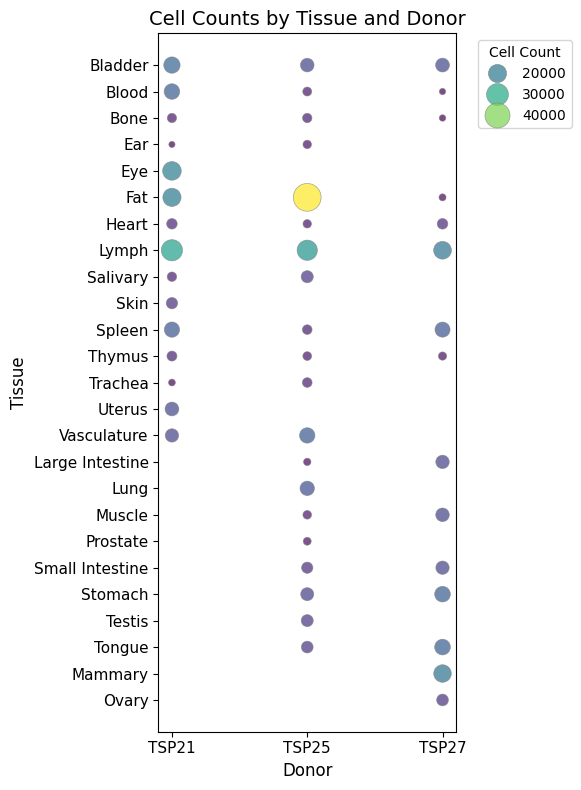

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("05_Merged-PerDonor-QC-h5ad/TSP_tissue_counts_matrix.csv", index_col=0)

# Rename tissue labels
df = df.rename(index={
    'Small': 'Small Intestine',
    'Large': 'Large Intestine'
})

# Convert to long format
df_long = df.reset_index().melt(id_vars='tissue', var_name='donor', value_name='count')

# Remove entries with count = 0
df_long = df_long[df_long['count'] > 0]

# Create the bubble plot
plt.figure(figsize=(6, 8))  # narrower figure to make donors closer
bubble_plot = sns.scatterplot(
    data=df_long,
    x='donor',
    y='tissue',
    size='count',
    hue='count',
    palette='viridis',
    sizes=(20, 400),
    alpha=0.7,
    edgecolor='gray',
    linewidth=0.5
)

# Titles and labels
plt.title('Cell Counts by Tissue and Donor', fontsize=14)
plt.xlabel('Donor', fontsize=12)
plt.ylabel('Tissue', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)


# Clean up legend
handles, labels = bubble_plot.get_legend_handles_labels()
bubble_plot.legend(handles=handles[1:], labels=labels[1:], title='Cell Count', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()
